# Imports

In [2]:
import numpy as np
import os

from more_itertools.recipes import reshape

from mnist.mnist import dummy_clf, n_correct
%load_ext autoreload
%autoreload 2
import sys
import os


# Get the current folder path and go up one level ('..') to the project root
project_root = os.path.abspath('..')

# Add the root to the system path so Python can find 'src'
if project_root not in sys.path:
    sys.path.append(project_root)
%load_ext autoreload
%autoreload 2
from keras.src.metrics import Precision
from keras.src.metrics.metrics_utils import confusion_matrix

np.random.seed(42) #to make results reproducible

# Matplotlib and seaborn configuration
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Function to Save figures


In [3]:
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "Classification"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id , tight_layout =True, fig_extension = "png", resolution=300):
    path = os.path.join(IMAGES_PATH , fig_id + "." + fig_extension )
    print("Saving figure", fig_id )
    if tight_layout:
        plt.tight_layout()
        plt.savefig(path, format = fig_extension,dpi=resolution)

# Importing Dataset

In [4]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml("mnist_784", version=1 , as_frame= False)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [5]:
print(mnist["frame"])
print(mnist["feature_names"])
print(mnist["target_names"])

None
['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7', 'pixel8', 'pixel9', 'pixel10', 'pixel11', 'pixel12', 'pixel13', 'pixel14', 'pixel15', 'pixel16', 'pixel17', 'pixel18', 'pixel19', 'pixel20', 'pixel21', 'pixel22', 'pixel23', 'pixel24', 'pixel25', 'pixel26', 'pixel27', 'pixel28', 'pixel29', 'pixel30', 'pixel31', 'pixel32', 'pixel33', 'pixel34', 'pixel35', 'pixel36', 'pixel37', 'pixel38', 'pixel39', 'pixel40', 'pixel41', 'pixel42', 'pixel43', 'pixel44', 'pixel45', 'pixel46', 'pixel47', 'pixel48', 'pixel49', 'pixel50', 'pixel51', 'pixel52', 'pixel53', 'pixel54', 'pixel55', 'pixel56', 'pixel57', 'pixel58', 'pixel59', 'pixel60', 'pixel61', 'pixel62', 'pixel63', 'pixel64', 'pixel65', 'pixel66', 'pixel67', 'pixel68', 'pixel69', 'pixel70', 'pixel71', 'pixel72', 'pixel73', 'pixel74', 'pixel75', 'pixel76', 'pixel77', 'pixel78', 'pixel79', 'pixel80', 'pixel81', 'pixel82', 'pixel83', 'pixel84', 'pixel85', 'pixel86', 'pixel87', 'pixel88', 'pixel89', 'pixel90', 'pixel91', 'p

In [6]:
print(mnist["categories"])

{'class': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']}


In [7]:
print("description" , mnist["DESCR"])
print("details", mnist["details"])
print("categories", mnist["categories"])
print("url", mnist["url"])

description **Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 2

In [8]:
X, y = mnist["data"], mnist["target"]
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


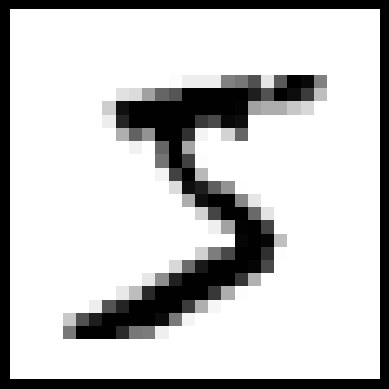

Saving figure some_digit_plot


<Figure size 640x480 with 0 Axes>

In [9]:
some_digit = X[0]
some_digit_image = some_digit.reshape(28,28)
plt.imshow(some_digit_image, cmap=mpl.cm.binary)
plt.axis("off")
plt.show()
save_fig("some_digit_plot")

In [10]:
y[0]

'5'

In [11]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

# 5 Detector


In [12]:
y_train_5 = (y_train == "5")
y_test_5 = (y_test == "5")

In [13]:
#lets pick a classifier now and train ,1st we go with stochastic Gradient Descent Classifier
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [15]:
sgd_clf.predict(some_digit.reshape(1, -1))

array([ True])

# Performance Measures

In [16]:
# cross validation
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [17]:
# is it correct?
#dummy classifier for no 5 elements

from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train)))

False


In [18]:
#this model accuracy
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")


array([0.90965, 0.90965, 0.90965])

it has over 90 percent accuracy for the no. is not 5 , only because 10 percent images are 5s , so most of the time is not 5 , here we can see that its not a good idea to use the accuracy as a good parameter to judge the classifier performance, especially for the skewed datasets. Here we use *Confusion Matrix (CM)*

In [19]:
# for more control on cross validation we can use StratifiedKfold

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3) #if dataset not shuffled already also add shuffle = True

for train_index , test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_folds = X_train[test_index]
    y_test_folds = y_train[test_index]

    clone_clf.fit(X_train_folds,y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct/len(y_pred))


TypeError: 'numpy.ndarray' object is not callable